# TurbineGuard — FD001 Exploratory Data Analysis

**Dataset.** NASA C-MAPSS *Turbofan Engine Degradation Simulation*, subset **FD001** — simulated
run-to-failure trajectories for a fleet of turbofan engines. Each row is one operating cycle of one
engine: an asset ID, a cycle counter, three operating settings, and twenty-one **anonymous** sensor
channels. The dataset documentation does not name the sensors, so this project deliberately does
**not** describe them as vibration, temperature, pressure, etc. — they are `sensor_01` … `sensor_21`.

**Input.** This notebook consumes the *validated Parquet outputs* produced by `make process`
(`data/processed/cmapss/FD001/`), never the raw text files. Parsing and validation logic lives in
`src/turbine_guard/data/` — see `docs/data_contract.md`.

**Scope (Loop 2).** Understand the data and derive implications for later feature engineering.
Out of scope by design: RUL label generation, train/validation splits, rolling-window features,
and model training — those belong to Loop 3+.

**Questions answered here**

1. How many train and test assets exist, and how long are their trajectories?
2. Are there missing, duplicate, or non-finite values?
3. Which columns are constant or near-constant?
4. How do the operating settings vary?
5. Which sensors change over an engine's life, and which look uninformative or noisy?
6. How correlated are the sensors with each other?
7. How different are the train and test distributions?
8. What data risks could affect later modeling, and what should Loop 3 do about them?

In [1]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

DATA_DIR = Path("..") / "data" / "processed" / "cmapss" / "FD001"

train = pd.read_parquet(DATA_DIR / "train_FD001.parquet")
test = pd.read_parquet(DATA_DIR / "test_FD001.parquet")
rul = pd.read_parquet(DATA_DIR / "rul_FD001.parquet")
report = json.loads((DATA_DIR / "processing_report.json").read_text(encoding="utf-8"))

SETTINGS = [c for c in train.columns if c.startswith("operating_setting_")]
SENSORS = [c for c in train.columns if c.startswith("sensor_")]

# Colorblind-safe palette (Okabe-Ito), fixed assignment throughout the notebook.
C_TRAIN, C_TEST, C_ACCENT, C_EXTRA = "#0072B2", "#E69F00", "#009E73", "#CC79A7"

plt.rcParams.update(
    {
        "figure.dpi": 110,
        "axes.spines.top": False,
        "axes.spines.right": False,
        "axes.grid": True,
        "grid.alpha": 0.25,
        "grid.linewidth": 0.6,
        "axes.titlesize": 11,
        "axes.labelsize": 10,
        "legend.frameon": False,
    }
)

print(
    f"processing report passed: {report['passed']}"
    f" | schema v{report['schema_version']}"
    f" | processing v{report['processing_version']}"
    f" | git {str(report['git_commit'])[:8]}"
)
train.head()

processing report passed: True | schema v1 | processing v1 | git 94ae6150


,asset_id,cycle,operating_setting_1,operating_setting_2,operating_setting_3,sensor_01,sensor_02,sensor_03,sensor_04,sensor_05,...,sensor_12,sensor_13,sensor_14,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,521.66,2388.02,8138.62,8.4195,0.03,392.0,2388.0,100.0,39.06,23.4190
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,522.28,2388.07,8131.49,8.4318,0.03,392.0,2388.0,100.0,39.00,23.4236
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,522.42,2388.03,8133.23,8.4178,0.03,390.0,2388.0,100.0,38.95,23.3442
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,...,522.86,2388.08,8133.83,8.3682,0.03,392.0,2388.0,100.0,38.88,23.3739
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,...,522.19,2388.04,8133.80,8.4294,0.03,393.0,2388.0,100.0,38.90,23.4044


## 1. Dataset overview

Train engines run **to failure**; test engines are **truncated** at some point before failure
(the official `RUL_FD001.txt` file states how many cycles each test engine had left — parsed and
validated here, but deliberately **not** joined to rows as a per-row label until Loop 3).

In [2]:
def overview(frame: pd.DataFrame, name: str) -> dict:
    lengths = frame.groupby("asset_id").size()
    return {
        "dataset": name,
        "rows": len(frame),
        "assets": frame["asset_id"].nunique(),
        "min length": int(lengths.min()),
        "median length": float(lengths.median()),
        "max length": int(lengths.max()),
    }


pd.DataFrame([overview(train, "train"), overview(test, "test")]).set_index("dataset")

,rows,assets,min length,median length,max length
dataset,,,,,
train,20631,100,128,199.0,362
test,13096,100,31,133.5,303


In [3]:
rul_summary = rul["rul"].describe().to_frame("official test RUL (cycles)").T
rul_summary

,count,mean,std,min,25%,50%,75%,max
official test RUL (cycles),100.0,75.52,41.76497,7.0,32.75,86.0,112.25,145.0


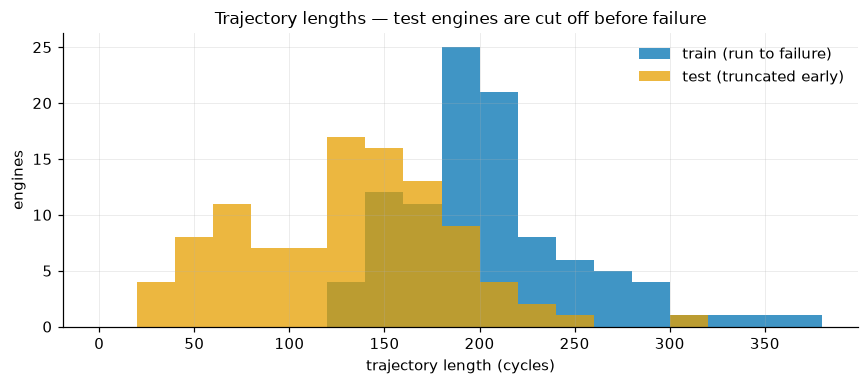

shortest test history: 31 cycles


In [4]:
train_lengths = train.groupby("asset_id").size()
test_lengths = test.groupby("asset_id").size()

fig, ax = plt.subplots(figsize=(8, 3.6))
bins = np.arange(0, 400, 20)
ax.hist(train_lengths, bins=bins, color=C_TRAIN, alpha=0.75, label="train (run to failure)")
ax.hist(test_lengths, bins=bins, color=C_TEST, alpha=0.75, label="test (truncated early)")
ax.set_xlabel("trajectory length (cycles)")
ax.set_ylabel("engines")
ax.set_title("Trajectory lengths — test engines are cut off before failure")
ax.legend()
plt.tight_layout()
plt.show()

print(f"shortest test history: {int(test_lengths.min())} cycles")

## 2. Data quality

The processing pipeline already enforces these as *required validation checks* (unique
`(asset_id, cycle)` pairs, contiguous cycles starting at 1, finite values); this cell
re-confirms them on the published Parquet.

In [5]:
def quality(frame: pd.DataFrame, name: str, numeric_columns: list[str]) -> dict:
    has_cycle = "cycle" in frame.columns
    return {
        "dataset": name,
        "missing values": int(frame.isna().sum().sum()),
        "non-finite values": int((~np.isfinite(frame[numeric_columns].to_numpy())).sum()),
        "duplicate (asset_id, cycle)": (
            int(frame.duplicated(["asset_id", "cycle"]).sum()) if has_cycle else 0
        ),
    }


pd.DataFrame(
    [
        quality(train, "train", SETTINGS + SENSORS),
        quality(test, "test", SETTINGS + SENSORS),
        quality(rul, "rul (official)", ["rul"]),
    ]
).set_index("dataset")

,missing values,non-finite values,"duplicate (asset_id, cycle)"
dataset,,,
train,0,0,0
test,0,0,0
rul (official),0,0,0


## 3. Constant and near-constant columns

Flagged by **relative** standard deviation (`std / |mean|`). One caveat this notebook checks
explicitly in section 5: a *tiny relative std does not prove a column is uninformative* — a sensor
with a large mean can still carry a clear degradation trend. Columns are reported, **not deleted**;
what to exclude is a Loop 3 feature-selection decision.

In [6]:
stats = train[SETTINGS + SENSORS].agg(["mean", "std", "min", "max"]).T
stats["relative std"] = stats["std"] / stats["mean"].abs().clip(lower=1e-12)
stats["distinct values"] = [train[c].nunique() for c in stats.index]

flagged = stats[stats["relative std"] < 1e-4].sort_values("relative std")
constant = list(flagged.index[flagged["std"] == 0.0])
near_constant = list(flagged.index[flagged["std"] > 0.0])
print("constant (train):      ", ", ".join(constant))
print("near-constant (train): ", ", ".join(near_constant))
flagged.round(6)

constant (train):       operating_setting_3, sensor_01, sensor_10, sensor_18, sensor_19
near-constant (train):  sensor_16, sensor_05, sensor_08, sensor_13, sensor_06


,mean,std,min,max,relative std,distinct values
operating_setting_3,100.000000,0.000000,100.00,100.00,0.000000,1
sensor_01,518.670000,0.000000,518.67,518.67,0.000000,1
sensor_10,1.300000,0.000000,1.30,1.30,0.000000,1
sensor_18,2388.000000,0.000000,2388.00,2388.00,0.000000,1
sensor_19,100.000000,0.000000,100.00,100.00,0.000000,1
sensor_16,0.030000,0.000000,0.03,0.03,0.000000,1
sensor_05,14.620000,0.000000,14.62,14.62,0.000000,1
sensor_08,2388.096652,0.070985,2387.90,2388.56,0.000030,53
sensor_13,2388.096152,0.071919,2387.88,2388.56,0.000030,56
sensor_06,21.609803,0.001389,21.60,21.61,0.000064,2


## 4. Operating settings

FD001 is the **single-operating-condition** C-MAPSS subset: `operating_setting_3` is constant and
settings 1–2 are only low-amplitude jitter around one nominal condition. They carry little
information here (the multi-condition subsets FD002/FD004 are where settings matter).

,count,mean,std,min,25%,50%,75%,max
operating_setting_1,20631.0,-0.00001,0.00219,-0.0087,-0.0015,0.0,0.0015,0.0087
operating_setting_2,20631.0,0.00000,0.00029,-0.0006,-0.0002,0.0,0.0003,0.0006
operating_setting_3,20631.0,100.00000,0.00000,100.0000,100.0000,100.0,100.0000,100.0000


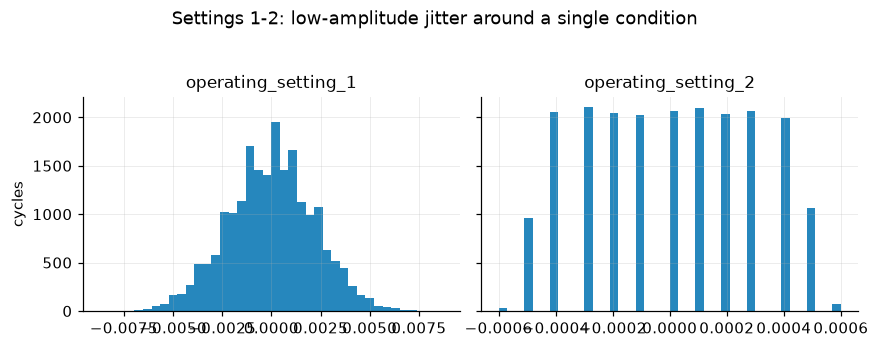

In [7]:
display(train[SETTINGS].describe().T.round(5))

fig, axes = plt.subplots(1, 2, figsize=(8, 3), sharey=True)
for ax, column in zip(axes, SETTINGS[:2]):
    ax.hist(train[column], bins=40, color=C_TRAIN, alpha=0.85)
    ax.set_title(column)
axes[0].set_ylabel("cycles")
fig.suptitle("Settings 1-2: low-amplitude jitter around a single condition", y=1.04)
plt.tight_layout()
plt.show()

## 5. Which sensors change over an engine's life?

For each train engine, compute the Spearman rank correlation between the **observed cycle
counter** and each sensor, then average across engines. This measures monotonic drift over the
lifecycle using only information available at prediction time — it is *not* a correlation with RUL
(that would need labels, which are Loop 3).

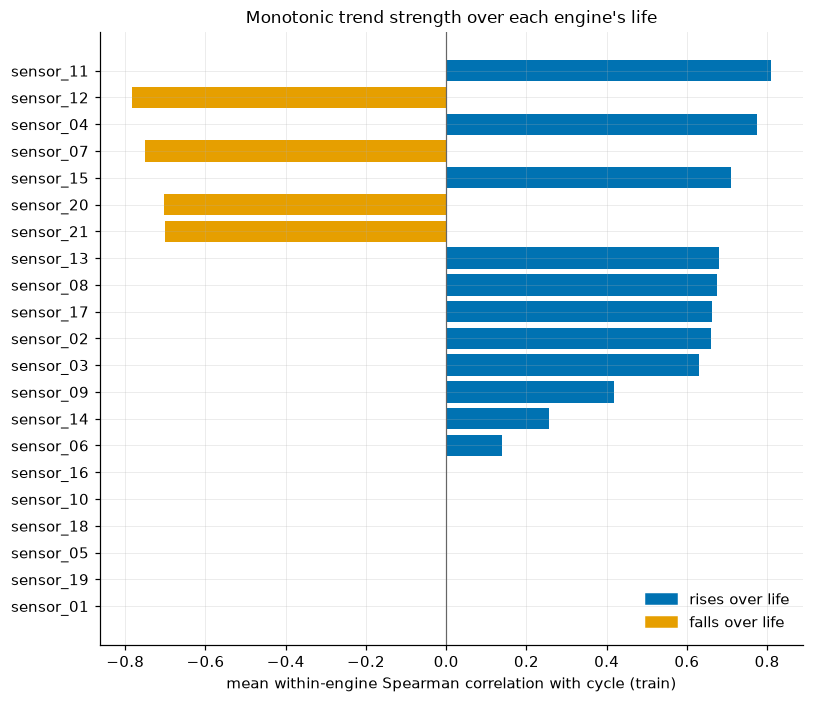

strongest monotonic trends: sensor_11, sensor_12, sensor_04, sensor_07
weak/no trend (|corr| < 0.1): sensor_10, sensor_05, sensor_16, sensor_18, sensor_19, sensor_01
note near-constant-by-relative-std sensors with a REAL trend: sensor_08, sensor_13


In [8]:
# Spearman = Pearson on ranks (avoids a SciPy dependency for one statistic).
# Constant-within-engine sensors have zero rank variance -> NaN, treated as no trend.
per_asset = []
with np.errstate(invalid="ignore", divide="ignore"):
    for _, group in train.groupby("asset_id"):
        ranked = group[[*SENSORS, "cycle"]].rank()
        per_asset.append(ranked[SENSORS].corrwith(ranked["cycle"]))
trend = pd.DataFrame(per_asset).mean().fillna(0.0)
trend_sorted = trend.iloc[np.argsort(np.abs(trend.to_numpy()))]

from matplotlib.patches import Patch

fig, ax = plt.subplots(figsize=(7.5, 6.5))
bar_colors = [C_TRAIN if value >= 0 else C_TEST for value in trend_sorted]
ax.barh(trend_sorted.index, trend_sorted.to_numpy(), color=bar_colors)
ax.axvline(0, color="0.4", linewidth=0.8)
ax.set_xlabel("mean within-engine Spearman correlation with cycle (train)")
ax.set_title("Monotonic trend strength over each engine's life")
ax.legend(
    handles=[
        Patch(color=C_TRAIN, label="rises over life"),
        Patch(color=C_TEST, label="falls over life"),
    ],
    loc="lower right",
)
plt.tight_layout()
plt.show()

trend_ranked = trend.abs().sort_values(ascending=False)
TOP_SENSORS = list(trend_ranked.index[:4])
weak = list(trend_ranked.index[trend_ranked < 0.1])
print("strongest monotonic trends:", ", ".join(TOP_SENSORS))
print("weak/no trend (|corr| < 0.1):", ", ".join(weak))
print(
    "note near-constant-by-relative-std sensors with a REAL trend:",
    ", ".join(s for s in near_constant if trend_ranked.get(s, 0) > 0.3) or "(none)",
)

## 6. Representative sensor trajectories

Raw traces of the strongest-trending sensors for three engines with short, median, and long
lives. The degradation signal is visible but **noisy** — the cycle-to-cycle scatter is why Loop 3
plans rolling-window features (means, slopes) rather than single-cycle values.

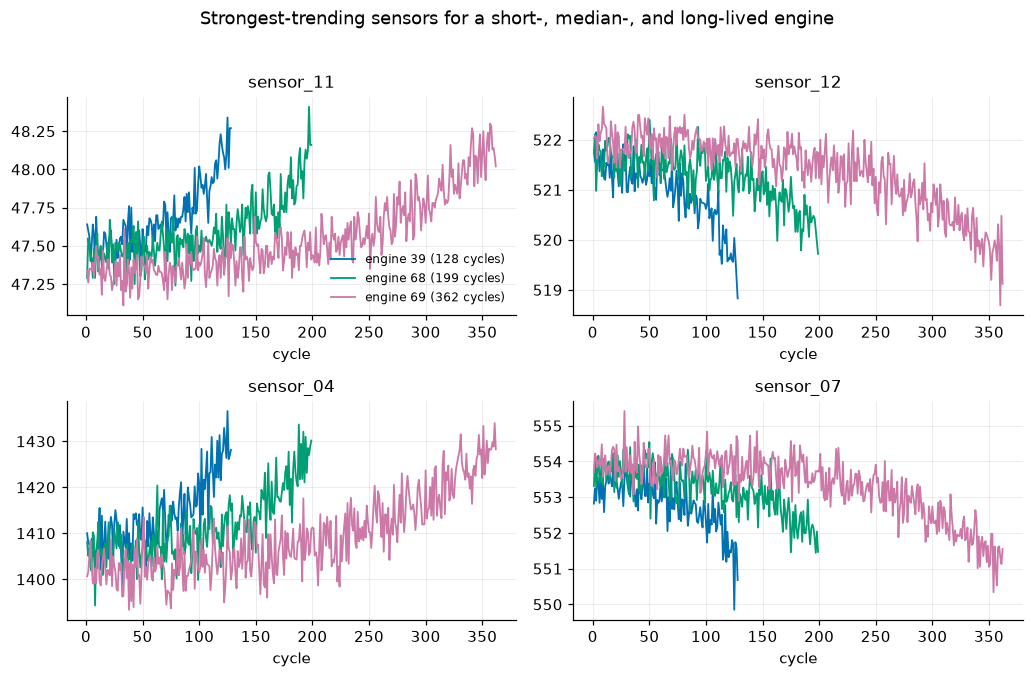

In [9]:
lengths_sorted = train_lengths.sort_values()
example_assets = [
    int(lengths_sorted.index[0]),
    int(lengths_sorted.index[len(lengths_sorted) // 2]),
    int(lengths_sorted.index[-1]),
]
asset_colors = dict(zip(example_assets, [C_TRAIN, C_ACCENT, C_EXTRA]))

fig, axes = plt.subplots(2, 2, figsize=(9.5, 6))
for ax, sensor in zip(axes.ravel(), TOP_SENSORS):
    for asset in example_assets:
        group = train[train["asset_id"] == asset]
        label = f"engine {asset} ({len(group)} cycles)"
        ax.plot(group["cycle"], group[sensor], color=asset_colors[asset], lw=1.2, label=label)
    ax.set_title(sensor)
    ax.set_xlabel("cycle")
axes[0, 0].legend(fontsize=8)
fig.suptitle("Strongest-trending sensors for a short-, median-, and long-lived engine", y=1.02)
plt.tight_layout()
plt.show()

## 7. Sensor distributions

Marginal distributions of every sensor that actually varies (train). Several are multi-modal or
heavy-tailed; nothing here justifies deleting "outliers" — late-life extreme values are exactly
the degradation signal a RUL model needs.

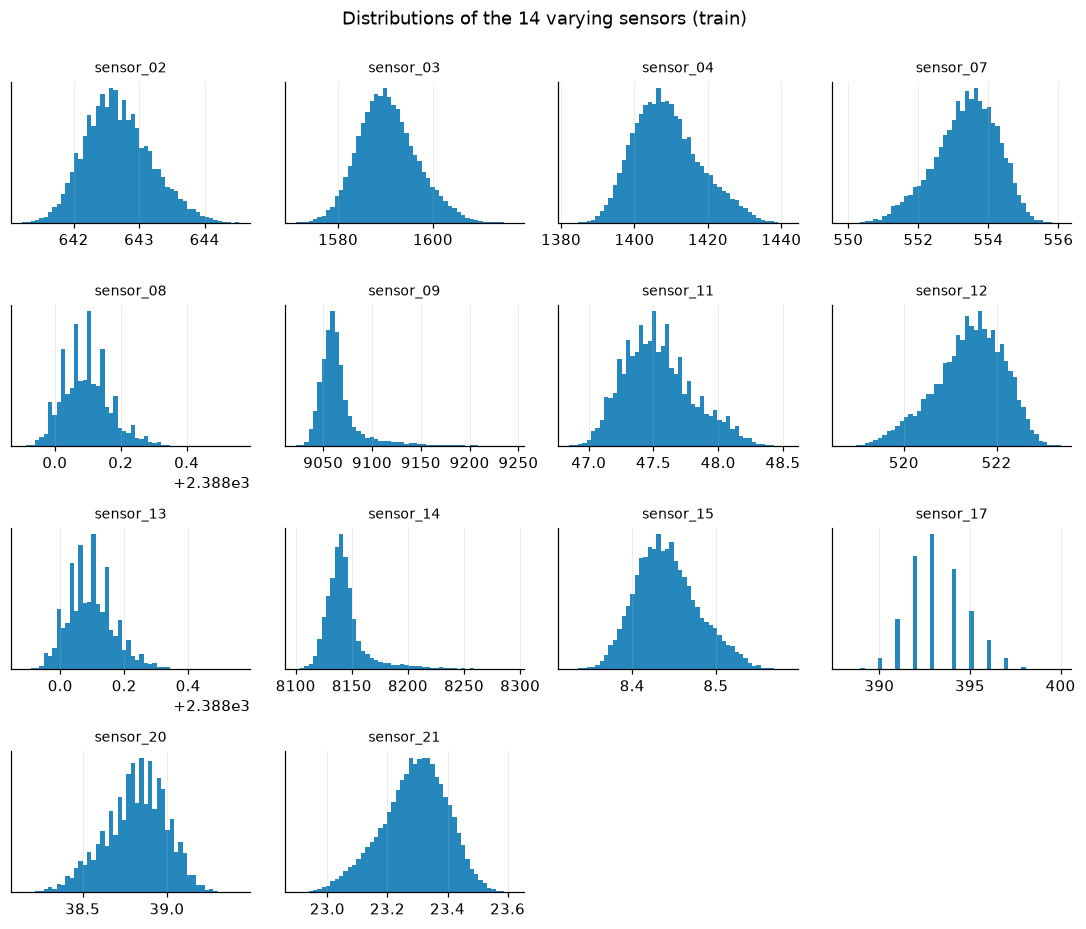

In [10]:
varying = [s for s in SENSORS if train[s].nunique() > 2]
ncols = 4
nrows = -(-len(varying) // ncols)

fig, axes = plt.subplots(nrows, ncols, figsize=(10, 2.1 * nrows))
for ax, sensor in zip(axes.ravel(), varying):
    ax.hist(train[sensor], bins=50, color=C_TRAIN, alpha=0.85)
    ax.set_title(sensor, fontsize=9)
    ax.set_yticks([])
for ax in axes.ravel()[len(varying) :]:
    ax.axis("off")
fig.suptitle(f"Distributions of the {len(varying)} varying sensors (train)", y=1.0)
plt.tight_layout()
plt.show()

## 8. Correlation structure

Pearson correlations among the varying sensors, settings 1–2, and the cycle counter (train).
Large same-sign blocks mean the sensors share a common degradation signal — expect strong
**multicollinearity**. Tree ensembles tolerate this; linear baselines will need regularization.

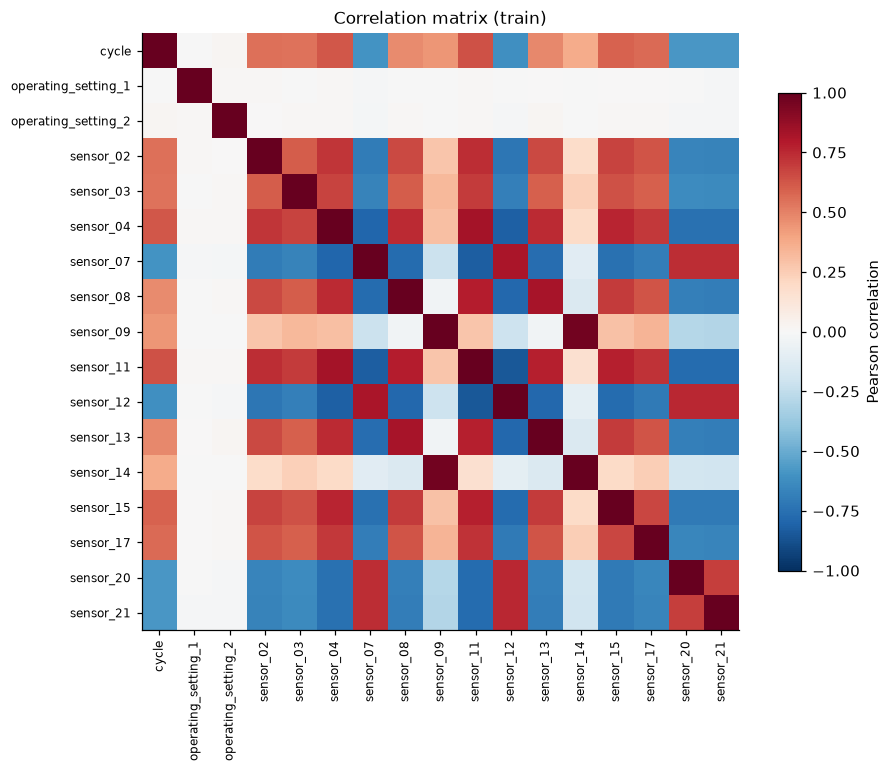

,,|r|
sensor_09,sensor_14,0.963
sensor_14,sensor_09,0.963
sensor_11,sensor_12,0.847
sensor_12,sensor_11,0.847
sensor_04,sensor_11,0.830
sensor_11,sensor_04,0.830
sensor_13,sensor_08,0.826
sensor_08,sensor_13,0.826


In [11]:
corr_columns = ["cycle", *SETTINGS[:2], *varying]
corr = train[corr_columns].corr()

fig, ax = plt.subplots(figsize=(8.5, 7))
image = ax.imshow(corr.to_numpy(), cmap="RdBu_r", vmin=-1, vmax=1)
ax.set_xticks(range(len(corr_columns)), corr_columns, rotation=90, fontsize=8)
ax.set_yticks(range(len(corr_columns)), corr_columns, fontsize=8)
ax.grid(False)
fig.colorbar(image, ax=ax, shrink=0.8, label="Pearson correlation")
ax.set_title("Correlation matrix (train)")
plt.tight_layout()
plt.show()

pair_corr = corr.where(~np.eye(len(corr), dtype=bool)).abs()
strongest = pair_corr.stack().sort_values(ascending=False)
strongest.head(8).to_frame("|r|").round(3)

## 9. Train versus test distributions

The comparison below is **expected to differ**, and understanding why matters: test trajectories
stop *before* failure, so the heavily degraded late-life states that dominate the tails of the
train distributions are under-represented in test. This is a mechanical censoring effect, not
sensor drift — but it is exactly the shape mismatch a monitoring system must not confuse with
drift later (Loop 9).

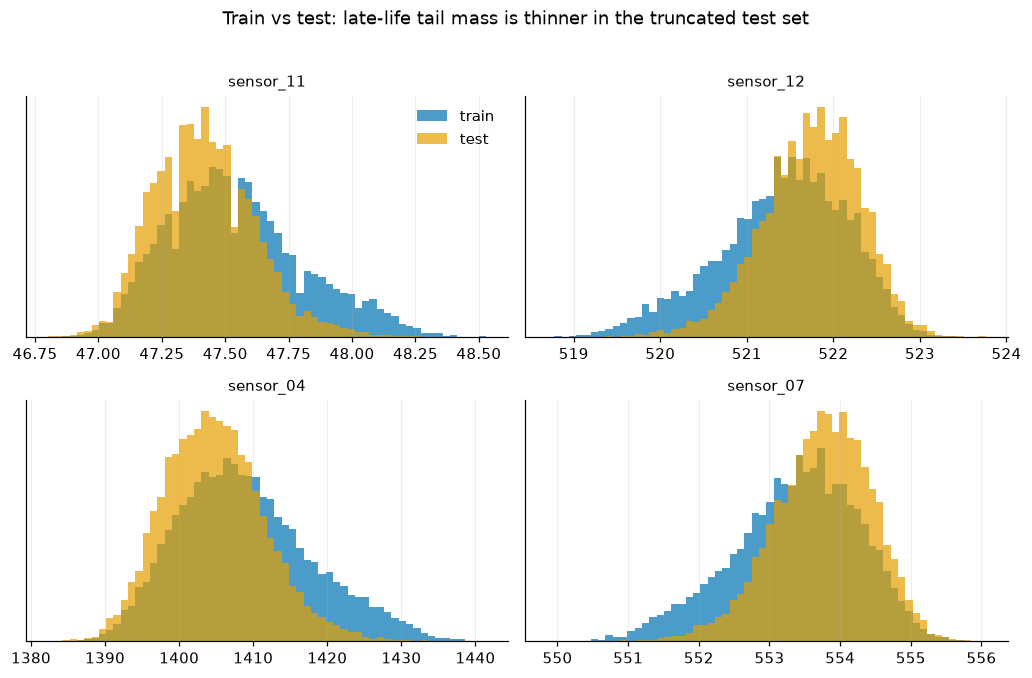

,train mean,test mean,train p95,test p95
sensor_11,47.541,47.416,48.045,47.75
sensor_12,521.413,521.748,522.500,522.59
sensor_04,1408.934,1404.735,1425.670,1416.28
sensor_07,553.368,553.758,554.690,554.80


In [12]:
fig, axes = plt.subplots(2, 2, figsize=(9.5, 6))
for ax, sensor in zip(axes.ravel(), TOP_SENSORS):
    bins = np.histogram_bin_edges(
        np.concatenate([train[sensor].to_numpy(), test[sensor].to_numpy()]), bins=60
    )
    ax.hist(train[sensor], bins=bins, density=True, color=C_TRAIN, alpha=0.7, label="train")
    ax.hist(test[sensor], bins=bins, density=True, color=C_TEST, alpha=0.7, label="test")
    ax.set_title(sensor, fontsize=10)
    ax.set_yticks([])
axes[0, 0].legend()
fig.suptitle("Train vs test: late-life tail mass is thinner in the truncated test set", y=1.02)
plt.tight_layout()
plt.show()

comparison = pd.DataFrame(
    {
        sensor: {
            "train mean": train[sensor].mean(),
            "test mean": test[sensor].mean(),
            "train p95": train[sensor].quantile(0.95),
            "test p95": test[sensor].quantile(0.95),
        }
        for sensor in TOP_SENSORS
    }
).T
comparison.round(3)

## 10. Findings and implications for Loop 3

**What the data looks like**

1. **100 train engines (20,631 rows, run to failure) and 100 test engines (13,096 rows,
   truncated)**, plus 100 official RUL values for the test engines. Train lives span
   128–362 cycles (median 199); test histories span 31–303 cycles (median ~134).
2. **Data quality is excellent**: no missing, duplicate, or non-finite values anywhere; cycles
   are contiguous from 1 for every engine. The validation pipeline enforces this on every
   reprocessing run.
3. **Uninformative columns exist and are known**: `operating_setting_3` and sensors 01, 10, 18,
   19 are constant; several others are near-constant by relative spread. FD001 has a single
   operating condition, so settings 1–2 are low-amplitude jitter with no structure.
4. **Relative spread is a misleading filter on its own**: sensors 08 and 13 have tiny relative
   std (large means) yet show clear monotonic trends over engine life. Trend strength, not raw
   variance, should drive feature selection.
5. **A core group of sensors trends monotonically with age** (both rising and falling families);
   a remainder shows weak or no trend and is mostly noise. Individual traces are noisy
   cycle-to-cycle even for the strongest sensors.
6. **Sensors are strongly mutually correlated** (shared degradation signal → multicollinearity).
7. **Train and test distributions differ mechanically** because test trajectories are censored
   before failure — thinner late-life tails, not drift.

**What Loop 3 should do about it**

- **Split by engine, never by row** — rows within an engine are strongly dependent.
- **Rolling-window features are justified**: trends are real but noisy, so rolling means /
  stds / slopes over recent cycles (5/10/20) should denoise them. All features at cycle *t*
  must use only cycles ≤ *t*, with an explicit automated leakage test.
- **Select features by trend/information content, not raw variance**; drop the constant columns,
  but do not drop sensors 08/13 on a variance heuristic.
- **Mind the shortest test history (31 cycles)**: feature windows and warm-up handling must
  produce valid features for short histories, or inference will fail on early-life engines.
- **Do not "clean" late-life extremes** — they are the signal.
- **Scaling/normalization (if a model needs it) must be fit on training engines only.**
- **The official RUL file stays out of the feature path**; it becomes the held-out benchmark
  only when evaluation arrives.
- **Expect multicollinearity**: fine for tree ensembles, needs regularization for linear
  baselines; interpretation of individual-sensor importances should be cautious.

*Loop 2 boundary respected: no RUL labels were created, no correlations with RUL computed, no
rolling features built, no splits made, and no models trained in this notebook.*